In [1]:
from anchoring_detection.preprocess import Preprocess

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn import svm
from sklearn.linear_model import SGDClassifier
from sklearn import metrics

import matplotlib.pyplot as plt
from mlxtend.plotting import plot_confusion_matrix

In [2]:
prepro = Preprocess()

Cargamos los datos de las simulaciones

In [3]:
# FUNCIONA
dataframes_surge, dataframes_sway = prepro.extract_res_files()

In [4]:
dataframes_surge['oc4__Hs1__Tp2__dir1__1']

,time[s],Surge
0,180.0,-5.67869
1,180.1,-5.67247
2,180.2,-5.66642
3,180.3,-5.66057
4,180.4,-5.65496
...,...,...
10196,1199.6,-4.24638
10197,1199.7,-4.24186
10198,1199.8,-4.23708
10199,1199.9,-4.23206


In [5]:
dataframes_sway['oc4__Hs1__Tp2__dir1__1']

,time[s],Sway
0,180.0,3.80982
1,180.1,3.80965
2,180.2,3.80952
3,180.3,3.80944
4,180.4,3.80942
...,...,...
10196,1199.6,5.17008
10197,1199.7,5.17448
10198,1199.8,5.17881
10199,1199.9,5.18303


Las señales requieren estabilización en el equilibrio porque se produce ligero hundimiento (por el error cometido en el cálculo manual de Fz de compensación de obra muerta). Con el siguiente método, solventamos este problema y aplicamos fft.

In [6]:
tff = prepro.fourier_python()

In [7]:
dataframes_surge['oc4__Hs2__Tp3__dir1__1']

,Frequencies,Amplitudes
0,0.000000,5.750392e-16
1,0.000980,9.291214e-02
2,0.001961,1.090917e-01
3,0.002941,1.040350e-01
4,0.003921,8.044447e-02
...,...,...
5095,4.994608,4.029734e-05
5096,4.995589,4.028932e-05
5097,4.996569,4.030096e-05
5098,4.997549,4.027051e-05


Determinamos los momentos espectrales de cada simulación

In [8]:
moments = prepro.moment_python()

In [9]:
moments

,m0_Surge,m2_Surge,m4_Surge,m0_Sway,m2_Sway,m4_Sway
oc4__Hs1__Tp2__dir1__1,0.002438,0.003567,0.047892,0.001749,0.003374,0.045315
oc4__Hs1__Tp2__dir1__2,0.011784,0.020603,0.276744,0.008595,0.015042,0.202063
oc4__Hs1__Tp2__dir2__1,0.002250,0.003548,0.047649,0.001852,0.002840,0.038124
oc4__Hs1__Tp2__dir2__2,0.011667,0.020584,0.276506,0.008593,0.014508,0.194887
oc4__Hs1__Tp2__dir3__1,0.002209,0.003746,0.050323,0.001888,0.002869,0.038510
...,...,...,...,...,...,...
oc4__Hs4__Tp5__dir3__2,0.012230,0.020804,0.279441,0.018121,0.027863,0.373985
oc4__Hs4__Tp5__dir4__1,0.005428,0.002837,0.037927,0.010878,0.014440,0.193691
oc4__Hs4__Tp5__dir4__2,0.012206,0.014142,0.189936,0.016706,0.025973,0.348638
oc4__Hs4__Tp5__dir5__1,0.011085,0.009327,0.124935,0.002734,0.003005,0.040322


Adjuntamos las etiquetas al dataset

In [11]:
cases = pd.read_csv(r'C:\Users\naval\Desktop\Arturo\Mooring_anomaly_detector\data\labels.csv', sep=';')

labels = cases.iloc[:, :3].set_index(moments.index)
state = cases.iloc[:, 3:].set_index(moments.index)

dataset = pd.concat([labels,moments,state],axis=1)

In [11]:
#dataset = dataset.sample(frac=1)

In [12]:
dataset

,Hs,Tp,Direction,m0_Surge,m2_Surge,m4_Surge,m0_Sway,m2_Sway,m4_Sway,Dragging
oc4__Hs1__Tp2__dir1__1,1.21,8.15,0,0.002438,0.003567,0.047892,0.001749,0.003374,0.045315,0
oc4__Hs1__Tp2__dir1__2,1.21,8.15,0,0.011784,0.020603,0.276744,0.008595,0.015042,0.202063,1
oc4__Hs1__Tp2__dir2__1,1.21,8.15,60,0.002250,0.003548,0.047649,0.001852,0.002840,0.038124,0
oc4__Hs1__Tp2__dir2__2,1.21,8.15,60,0.011667,0.020584,0.276506,0.008593,0.014508,0.194887,1
oc4__Hs1__Tp2__dir3__1,1.21,8.15,90,0.002209,0.003746,0.050323,0.001888,0.002869,0.038510,0
...,...,...,...,...,...,...,...,...,...,...
oc4__Hs4__Tp5__dir3__2,8.10,18.69,90,0.012230,0.020804,0.279441,0.018121,0.027863,0.373985,1
oc4__Hs4__Tp5__dir4__1,8.10,18.69,120,0.005428,0.002837,0.037927,0.010878,0.014440,0.193691,0
oc4__Hs4__Tp5__dir4__2,8.10,18.69,120,0.012206,0.014142,0.189936,0.016706,0.025973,0.348638,1
oc4__Hs4__Tp5__dir5__1,8.10,18.69,180,0.011085,0.009327,0.124935,0.002734,0.003005,0.040322,0


array([[<Axes: title={'center': 'Hs'}>, <Axes: title={'center': 'Tp'}>,
        <Axes: title={'center': 'Direction'}>],
       [<Axes: title={'center': 'm0_Surge'}>,
        <Axes: title={'center': 'm2_Surge'}>,
        <Axes: title={'center': 'm4_Surge'}>],
       [<Axes: title={'center': 'm0_Sway'}>,
        <Axes: title={'center': 'm2_Sway'}>,
        <Axes: title={'center': 'm4_Sway'}>],
       [<Axes: title={'center': 'Dragging'}>, <Axes: >, <Axes: >]],
      dtype=object)

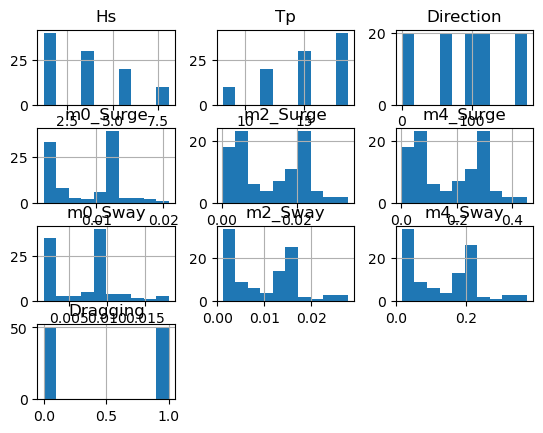

In [13]:
dataset.hist()

<Axes: >

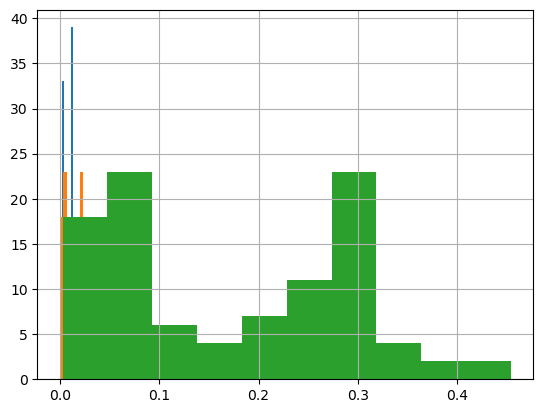

In [14]:
dataset['m0_Surge'].hist()
dataset['m2_Surge'].hist()
dataset['m4_Surge'].hist()

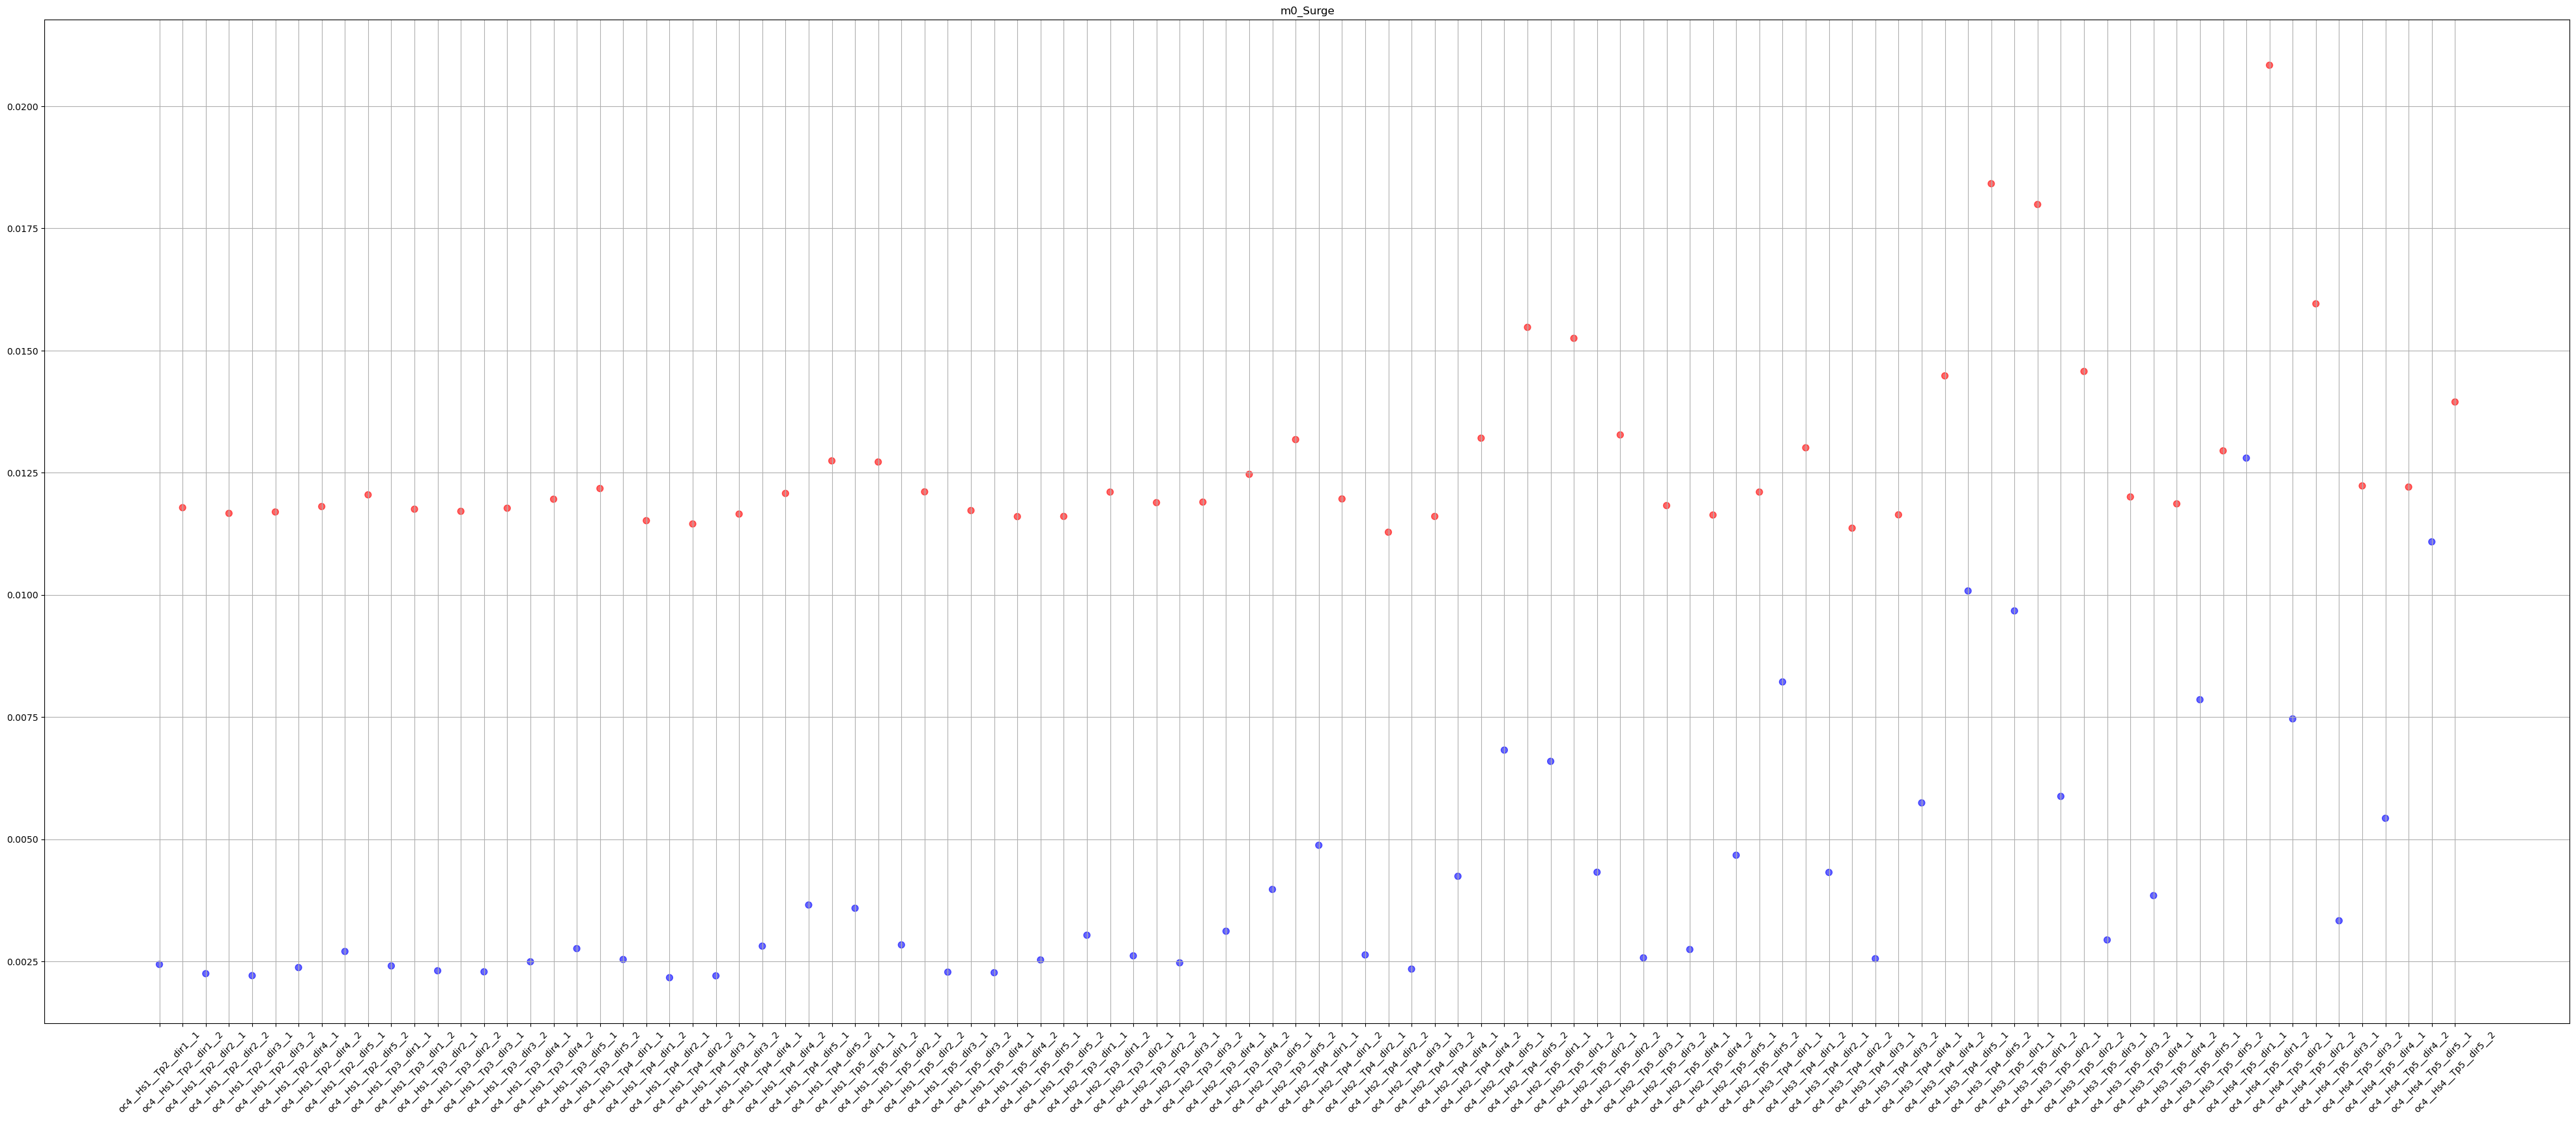

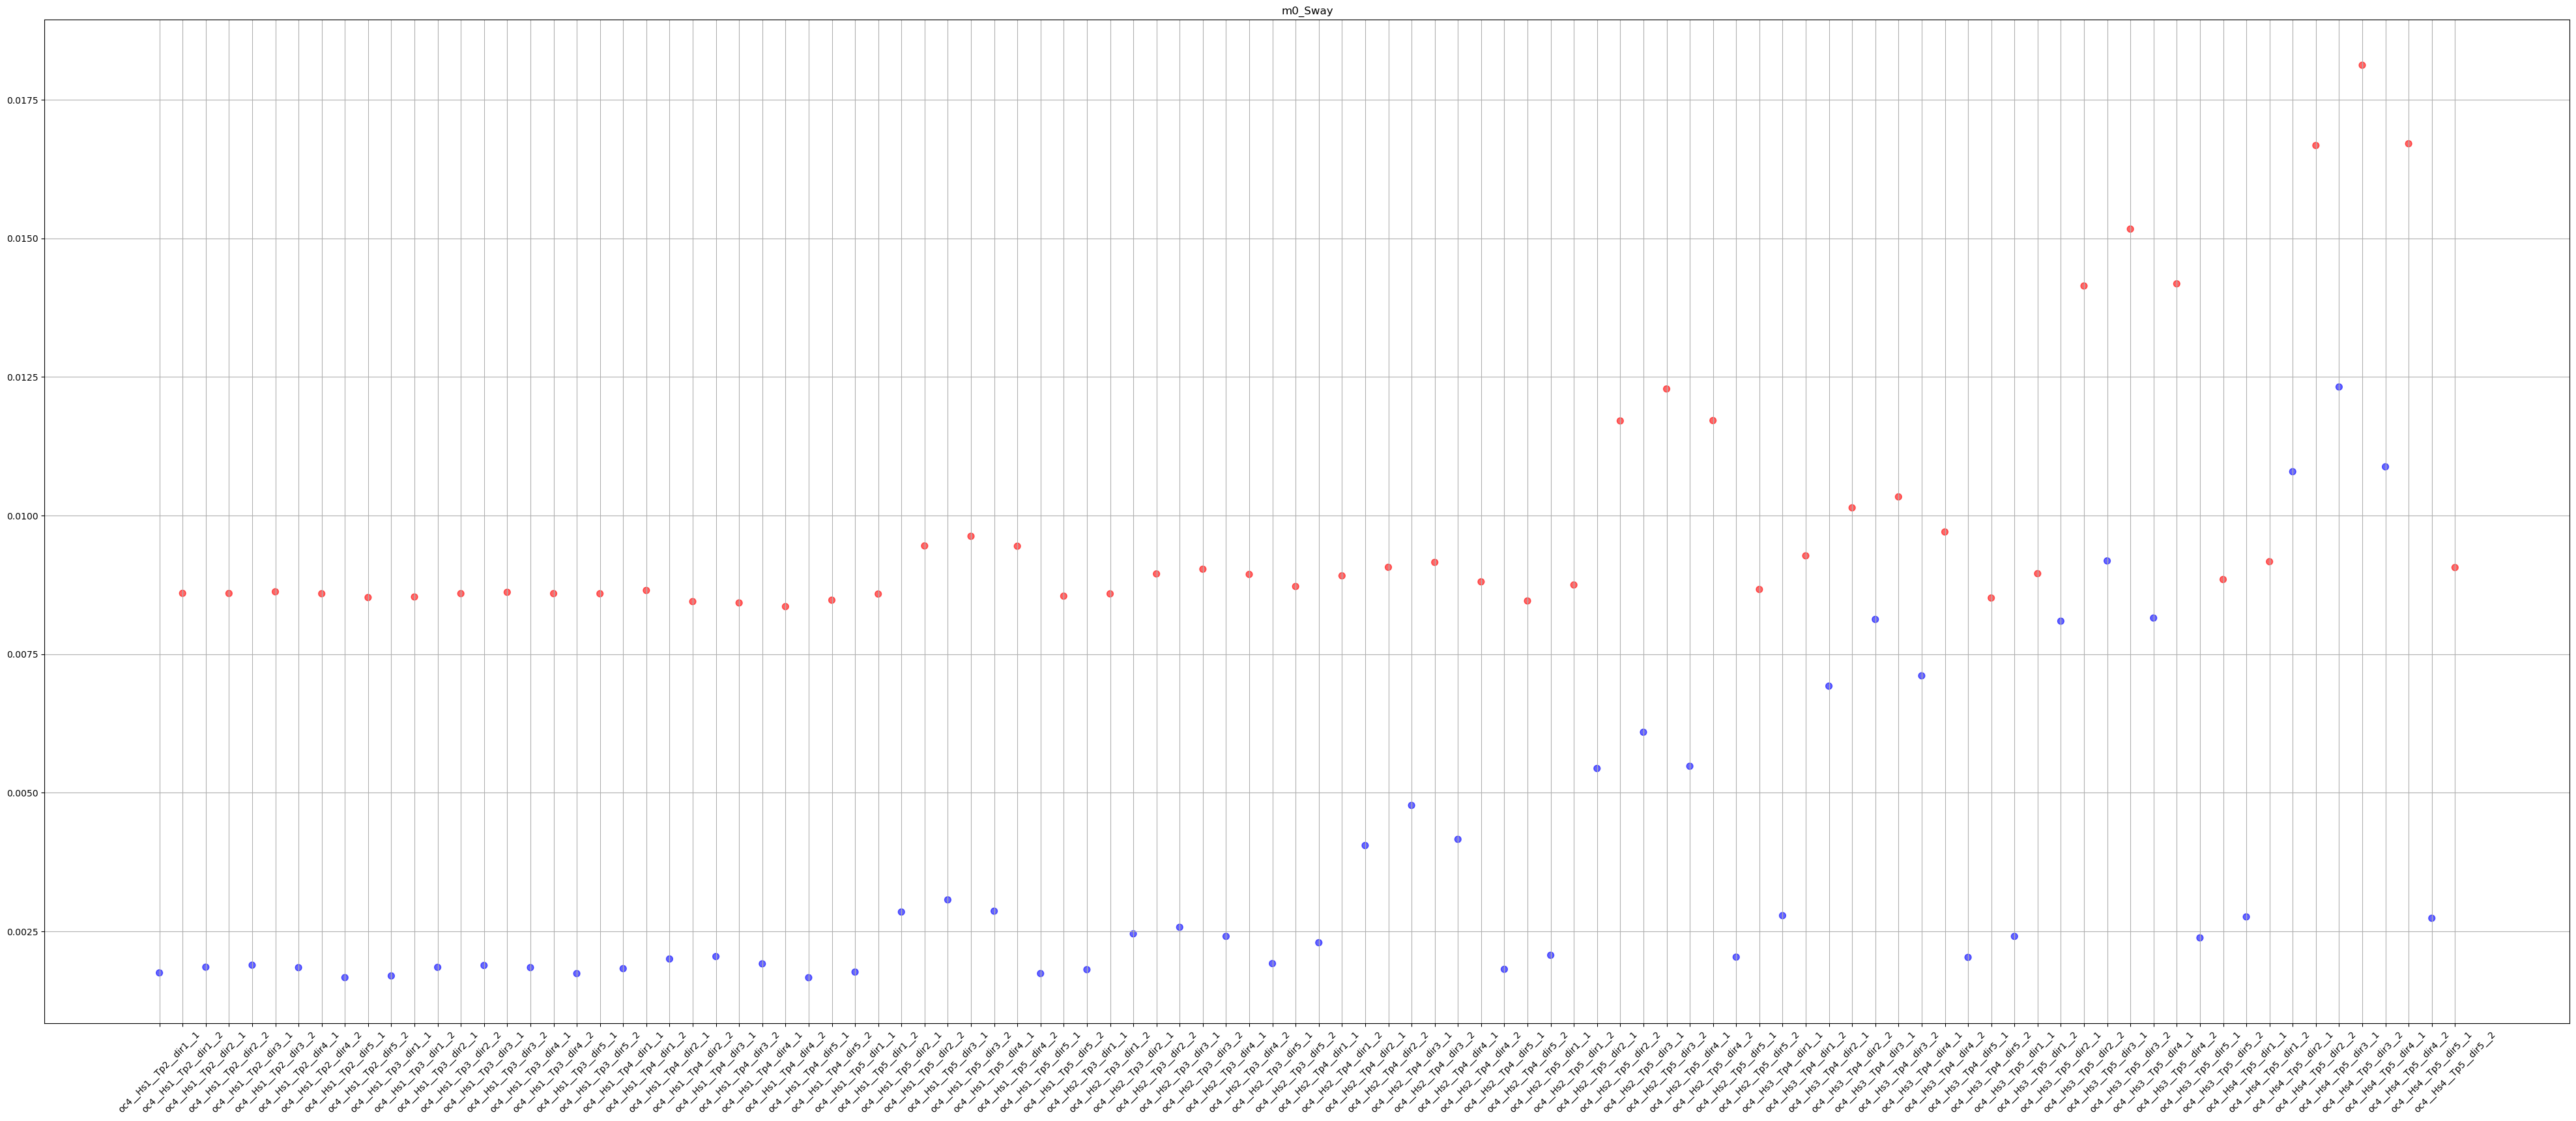

In [22]:
moves = ['Surge','Sway']
for mov in moves:
    plt.figure(figsize=(50,20))
    colors = dataset['Dragging'].map({1: 'r', 0: 'b'})
    plt.scatter(dataset.index,dataset[f'm0_{mov}'],color=colors, alpha=0.6, s=50)
    plt.xticks(rotation=45)
    plt.title(f"m0_{mov}")
    plt.grid()

Se requiere dividir los dataframes en datos de train y test, ademas de escalar y normalizar los momentos

In [50]:
X = dataset[['m0_Surge', 'm2_Surge', 'm4_Surge', 'm0_Sway', 'm2_Sway', 'm4_Sway']]
Y = dataset['Dragging']

In [53]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [54]:
X_train

,m0_Surge,m2_Surge,m4_Surge,m0_Sway,m2_Sway,m4_Sway
oc4__Hs2__Tp4__dir3__2,0.011605,0.020139,0.270527,0.009154,0.008963,0.120311
oc4__Hs3__Tp5__dir5__1,0.007855,0.005536,0.074106,0.002380,0.003081,0.041360
oc4__Hs1__Tp4__dir4__1,0.002813,0.004677,0.062812,0.001912,0.001333,0.017871
oc4__Hs2__Tp3__dir2__1,0.002614,0.003238,0.043458,0.002453,0.001623,0.021715
oc4__Hs2__Tp5__dir5__2,0.012104,0.015218,0.204387,0.008665,0.014795,0.198735
...,...,...,...,...,...,...
oc4__Hs2__Tp5__dir1__1,0.006594,0.009600,0.128817,0.002067,0.003256,0.043719
oc4__Hs3__Tp4__dir1__2,0.013009,0.011150,0.149606,0.009272,0.016086,0.216053
oc4__Hs1__Tp3__dir3__1,0.002287,0.003978,0.053437,0.001882,0.002628,0.035280
oc4__Hs4__Tp5__dir2__1,0.007462,0.010311,0.138340,0.010790,0.014594,0.195760


In [55]:
min_max_scaler = MinMaxScaler()
X_train_min_max = min_max_scaler.fit_transform(X_train)
X_test_min_max = min_max_scaler.transform(X_test)

In [56]:
X_train_min_max

array([[5.04500640e-01, 5.93182632e-01, 5.93629860e-01, 4.55158355e-01,
        2.91772877e-01, 2.91831610e-01],
       [3.03228249e-01, 1.58431588e-01, 1.58081155e-01, 4.36359741e-02,
        7.13351041e-02, 7.14279340e-02],
       [3.26131792e-02, 1.32853642e-01, 1.33038695e-01, 1.51920119e-02,
        5.83090246e-03, 5.85685097e-03],
       [2.19380042e-02, 9.00101569e-02, 9.01225459e-02, 4.80576861e-02,
        1.67160450e-02, 1.65874118e-02],
       [5.31270921e-01, 4.46676039e-01, 4.46970802e-01, 4.25489346e-01,
        5.10299131e-01, 5.10765059e-01],
       [5.13528602e-01, 6.19229751e-01, 6.19676315e-01, 4.22374363e-01,
        4.91611367e-01, 4.92064646e-01],
       [4.45846522e-02, 5.36622201e-02, 5.36436683e-02, 8.79549088e-03,
        7.04053133e-02, 7.05339454e-02],
       [1.72981673e-01, 7.80824559e-02, 7.78576463e-02, 5.59902401e-01,
        4.97014293e-01, 4.96682318e-01],
       [5.28233938e-01, 6.31856667e-01, 6.32253220e-01, 4.16633467e-01,
        5.09505891e-01, 

In [57]:
X_test_min_max

array([[ 6.63733468e-01,  7.52653892e-01,  7.52978349e-01,
         7.58073966e-01,  8.17600244e-01,  8.17826268e-01],
       [ 4.87173885e-01,  5.07430144e-01,  5.07790482e-01,
         4.49767435e-01,  3.33060477e-01,  3.33200520e-01],
       [ 3.22760367e-01,  1.68140185e-01,  1.67840846e-01,
         6.79966552e-02,  1.22702669e-01,  1.22791769e-01],
       [ 5.20230823e-01,  6.23639905e-01,  6.24075238e-01,
         4.47677483e-01,  4.48900840e-01,  4.49225327e-01],
       [ 1.42889728e-02,  1.16611169e-01,  1.16784884e-01,
         5.52338829e-02,  1.19862670e-02,  1.18346858e-02],
       [ 5.04519910e-01,  5.58129373e-01,  5.58553937e-01,
         4.18150844e-01,  5.12860680e-01,  5.13347717e-01],
       [-2.04055519e-03,  7.18553360e-02,  7.20170636e-02,
         2.04837467e-02,  1.41666851e-02,  1.41971446e-02],
       [ 4.00758713e-01,  3.88297093e-01,  3.88125371e-01,
         4.52471499e-02,  7.77884885e-02,  7.78919548e-02],
       [ 1.08575442e-02,  9.05242596e-02,  9.068

## Modelos

### SGD

In [58]:
sgd_clf = SGDClassifier()

In [59]:
sgd_clf.fit(X_train_min_max,Y_train)

SGDClassifier()

In [60]:
Y_pred_sgd = sgd_clf.predict(X_test_min_max)

Métricas

In [65]:
rmse_sgd = np.sqrt(metrics.mean_squared_error(Y_test, Y_pred_sgd))
acu_sgd = metrics.accuracy_score(Y_test,Y_pred_sgd)
precision_sgd = metrics.precision_score(Y_test,Y_pred_sgd)
recall_sgd = metrics.recall_score(Y_test,Y_pred_sgd)
f1_sgd = metrics.f1_score(Y_test,Y_pred_sgd)

print(f"% ERROR --> {rmse_sgd*100} %")
print(f"% ACURACCY --> {acu_sgd*100} %")
print(f"% PRECISION --> {precision_sgd*100} %")
print(f"% RECALL --> {recall_sgd*100} %")
print(f"% f1 --> {f1_sgd*100} %")

% ERROR --> 22.360679774997898 %
% ACURACCY --> 95.0 %
% PRECISION --> 100.0 %
% RECALL --> 87.5 %
% f1 --> 93.33333333333333 %


matriz de confusión

In [62]:
cm = metrics.confusion_matrix(Y_test,Y_pred_sgd)
cm

array([[12,  0],
       [ 1,  7]], dtype=int64)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

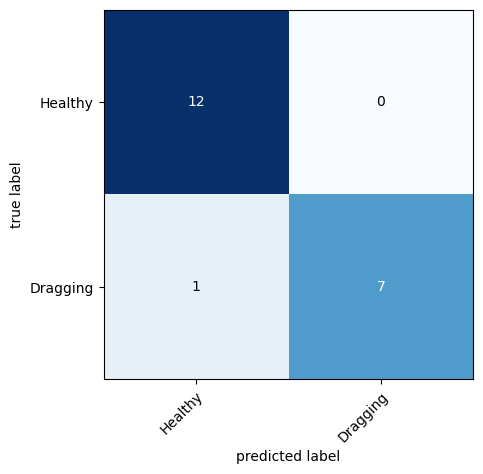

In [63]:
dragging = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=dragging)

In [36]:
print(Y_test)
print(Y_pred_sgd)

oc4__Hs1__Tp4__dir4__1    0
oc4__Hs3__Tp5__dir4__1    0
oc4__Hs1__Tp2__dir2__1    0
oc4__Hs2__Tp4__dir3__2    1
oc4__Hs3__Tp4__dir3__2    1
oc4__Hs4__Tp5__dir2__2    1
oc4__Hs1__Tp3__dir4__1    0
oc4__Hs3__Tp4__dir2__2    1
oc4__Hs2__Tp4__dir3__1    0
oc4__Hs4__Tp5__dir3__2    1
oc4__Hs2__Tp4__dir2__2    1
oc4__Hs4__Tp5__dir2__1    0
oc4__Hs3__Tp4__dir5__1    0
oc4__Hs1__Tp3__dir2__2    1
oc4__Hs1__Tp2__dir4__2    1
oc4__Hs1__Tp5__dir1__1    0
oc4__Hs1__Tp4__dir2__1    0
oc4__Hs1__Tp4__dir3__1    0
oc4__Hs1__Tp5__dir2__2    1
oc4__Hs1__Tp2__dir5__1    0
Name: Dragging, dtype: int64
[0 0 0 1 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 0]


### SVM

In [36]:
svm_clf = svm.SVC()

In [38]:
svm_clf.fit(X_train_min_max,Y_train)

SVC()

In [39]:
Y_pred = svm_clf.predict(X_test_min_max)

In [41]:
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
print(f"% ERROR --> {rmse*100} %")

% ERROR --> 22.360679774997898 %
